# DATA 201 Capstone Project: Citi Bike Summer Usage Analysis  
## Preparing for the 2026 FIFA World Cup

### Motivation
New York City has the highest Citi Bike usage in summer because of warm weather, tourism, and outdoor events.  

The **2026 FIFA World Cup** will bring millions of fans to the New York/New Jersey area, with the **World Cup Final on July 19, 2026** at MetLife Stadium.  

By studying July 2025 (a busy summer month right before the tournament), we can understand current patterns between casual riders (mostly tourists) and annual members. These insights will help Citi Bike improve bike availability, promote electric bikes, and create better marketing campaigns for the big crowds in 2026. This supports sustainable transportation and makes the visitor experience smoother.



### Data Source
We use the official **Citi Bike trip data** for July 2025.  
- Download link: https://s3.amazonaws.com/tripdata/202507-citibike-tripdata.zip  
- The file contains about 2–3 million rides (rows) and 13–15 columns.  
- Important columns: ride_id, rideable_type (classic or electric), started_at, ended_at, member_casual (casual or member), etc.  

This data is publicly available from Citi Bike / Lyft.

### Step 1: Import Libraries and Load the Data
We import basic libraries and download the July 2025 data.

In [2]:
# Import the libraries we need
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats   # for the statistical test


In [3]:
# Download and load the data
url = url = "https://s3.amazonaws.com/tripdata/202507-citibike-tripdata.zip"

In [4]:
import zipfile
import requests
from io import BytesIO


response = requests.get(url)
with zipfile.ZipFile(BytesIO(response.content)) as z:
    df_list = [pd.read_csv(z.open(f)) for f in z.namelist() if f.endswith('.csv')]
df = pd.concat(df_list, ignore_index=True)

/tmp/ipykernel_3592/447553090.py:8: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(z.open(f)) for f in z.namelist() if f.endswith('.csv')]
/tmp/ipykernel_3592/447553090.py:8: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(z.open(f)) for f in z.namelist() if f.endswith('.csv')]
/tmp/ipykernel_3592/447553090.py:8: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(z.open(f)) for f in z.namelist() if f.endswith('.csv')]
/tmp/ipykernel_3592/447553090.py:8: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(z.open(f)) for f in z.namelist() if f.endswith('.csv')]
/tmp/ipykernel_3592/447553090.py:8: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=Fal

In [5]:
df

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,4DD2787D61CF3241,electric_bike,2025-07-18 17:25:37.739,2025-07-18 17:47:53.285,49 St & 25 Ave,6804.01,48 St & Broadway,6629.06,40.764496,-73.904632,40.755763,-73.912715,casual
1,773CBF1A04FD71AB,electric_bike,2025-07-19 15:28:29.468,2025-07-19 16:04:17.964,Central Park S & 6 Ave,6876.04,5 Ave & E 72 St,7100.07,40.765909,-73.976342,40.772828,-73.966853,casual
2,D68E54237896E734,electric_bike,2025-07-17 23:27:57.316,2025-07-17 23:40:52.640,Leonard St & Church St,5359.11,Liberty St & Broadway,5105.01,40.717571,-74.005549,40.709056,-74.010434,casual
3,925D499017AC875C,electric_bike,2025-07-24 13:37:21.526,2025-07-24 13:44:39.234,Central Park S & 6 Ave,6876.04,5 Ave & E 72 St,7100.07,40.765909,-73.976342,40.772828,-73.966853,casual
4,2E66E951D8461F26,electric_bike,2025-07-27 18:58:50.703,2025-07-27 19:21:55.612,Central Park S & 6 Ave,6876.04,5 Ave & E 72 St,7100.07,40.765909,-73.976342,40.772828,-73.966853,casual
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4988048,D67680B8F55CD63B,classic_bike,2025-07-02 15:52:13.622,2025-07-02 16:05:43.590,E 4 St & Ave B,5515.08,E 22 St & 2 Ave,5971.09,40.723347,-73.982659,40.737169,-73.981225,casual
4988049,9FCE417C5B5D8D24,electric_bike,2025-07-04 19:12:49.316,2025-07-04 19:37:21.340,E 26 St & 3 Ave,6089.11,Market St & Henry St,5270.09,40.740693,-73.981606,40.713107,-73.994464,casual
4988050,A6546FC3F685D408,electric_bike,2025-07-02 13:17:23.726,2025-07-02 13:46:07.592,Riverside Dr & W 82 St,7388.10,Lafayette St & E 8 St,5788.13,40.787209,-73.981281,40.730207,-73.991026,member
4988051,49B8E6FA2714D82E,classic_bike,2025-07-13 17:30:04.622,2025-07-13 17:48:58.953,Riverside Dr & W 82 St,7388.10,Riverside Dr & W 82 St,7388.10,40.787209,-73.981281,40.787209,-73.981281,member


In [6]:
df.shape

(4988053, 13)

In [7]:
df.index

RangeIndex(start=0, stop=4988053, step=1)

Data Cleaning and Transformations

In [8]:
# Set the index
# Transformation 1: Convert started_at and ended_at to datetime format
df['started_at'] = pd.to_datetime(df['started_at'])
df['ended_at'] = pd.to_datetime(df['ended_at'])

In [9]:
# Transformation 2: Create a new column for trip duration in minutes
df['trip_duration_min'] = (df['ended_at'] - df['started_at']).dt.total_seconds() / 60

In [10]:
# Transformation 3: Create columns for hour of day, day of week, and weekend flag
df['hour'] = df['started_at'].dt.hour
df['day_of_week'] = df['started_at'].dt.day_name()
df['is_weekend'] = df['started_at'].dt.weekday >= 5   # True if Saturday or Sunday

In [11]:
# Transformation 4: Make rider type and bike type lowercase (easier to work with)
df['member_casual'] = df['member_casual'].str.lower()
df['rideable_type'] = df['rideable_type'].str.lower()

In [13]:
# Transformation 5: Remove unrealistic trips (keep only trips between 1 minute and 4 hours)
df = df[(df['trip_duration_min'] >= 1) & (df['trip_duration_min'] <= 240)].copy()

In [15]:
print(df.shape)
df.describe()

(4979820, 17)


,started_at,ended_at,start_lat,start_lng,end_lat,end_lng,trip_duration_min,hour
count,4979820,4979820,4.976847e+06,4.976847e+06,4.964119e+06,4.964119e+06,4.979820e+06,4.979820e+06
mean,2025-07-17 02:11:34.217576448,2025-07-17 02:24:42.974451200,4.073650e+01,-7.397143e+01,4.073634e+01,-7.397150e+01,1.314595e+01,1.416490e+01
min,2025-06-30 21:24:37.731000,2025-07-01 00:00:00.417000,4.063338e+01,-7.402682e+01,4.063338e+01,-7.408084e+01,1.000167e+00,0.000000e+00
25%,2025-07-09 18:44:40.849499904,2025-07-09 18:57:39.354500096,4.071222e+01,-7.399209e+01,4.071186e+01,-7.399213e+01,5.512533e+00,1.000000e+01
50%,2025-07-17 10:14:42.216499968,2025-07-17 10:26:29.408500224,4.073532e+01,-7.397898e+01,4.073522e+01,-7.397898e+01,9.498583e+00,1.500000e+01
75%,2025-07-24 13:45:36.347500032,2025-07-24 13:57:50.629750016,4.076009e+01,-7.395482e+01,4.075992e+01,-7.395482e+01,1.642252e+01,1.800000e+01
max,2025-07-31 23:57:27.342000,2025-07-31 23:59:54.705000,4.088630e+01,-7.384672e+01,4.088630e+01,-7.384672e+01,2.399747e+02,2.300000e+01
std,NaN,NaN,4.037707e-02,2.911051e-02,4.033307e-02,2.915633e-02,1.301859e+01,5.260576e+00


Explanation:
These steps fix the date columns, calculate how long each ride was, pull out the hour and day, and remove bad data (very short or very long trips are usually errors). Now the data is ready for analysis.

In [16]:
# Descriptive statistics: average trip duration by rider type
print("Average Trip Duration by Rider Type:")
print(df.groupby('member_casual')['trip_duration_min'].describe())

Average Trip Duration by Rider Type:
                   count       mean        std       min     25%        50%  \
member_casual                                                                 
casual         1048657.0  18.872761  19.289936  1.000983  7.8757  13.294033   
member         3931163.0  11.618292  10.215280  1.000167  5.0909   8.692500   

                     75%         max  
member_casual                         
casual         22.897150  239.974667  
member         14.869392  239.897117  


In [17]:
# Inferential statistics: t-test to see if casual riders take longer trips than members
casual = df[df['member_casual'] == 'casual']['trip_duration_min']
member = df[df['member_casual'] == 'member']['trip_duration_min']

t_stat, p_value = stats.ttest_ind(casual, member, equal_var=False)

In [18]:
print("\nT-test Results:")
print(f"p-value: {p_value:.5f}")
if p_value < 0.05:
    print("→ Yes, there is a statistically significant difference in trip lengths between casual and member riders.")
else:
    print("→ No significant difference found.")


T-test Results:
p-value: 0.00000
→ Yes, there is a statistically significant difference in trip lengths between casual and member riders.


Explanation:
The groupby() shows summary numbers (mean, min, max). The t-test tells us if the difference in trip duration between casual and member riders is real or just by chance. This is our required statistical analysis.


Step 4: Data Visualizations
Here are three easy-to-understand graphs.

In [19]:
import seaborn as sns

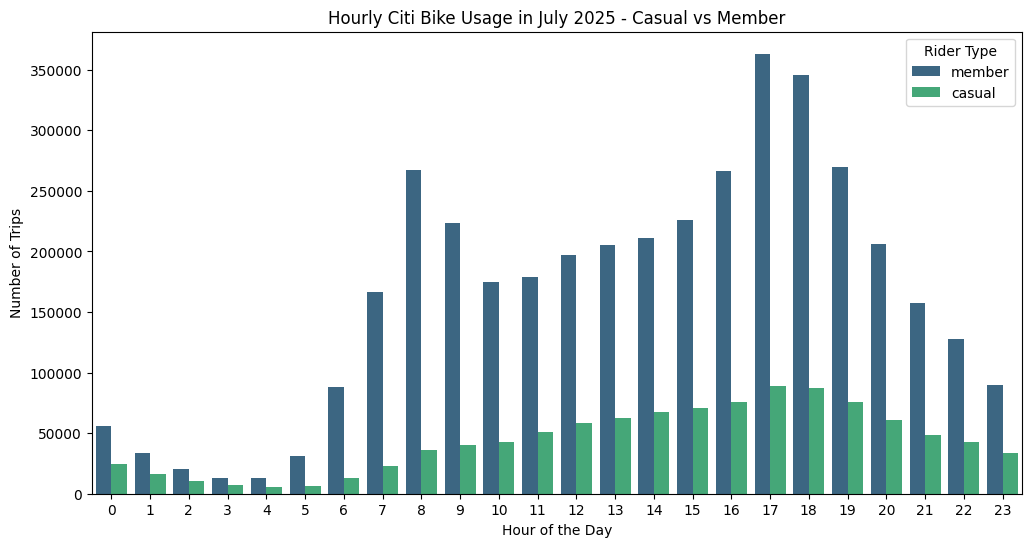

In [20]:
# Graph 1: Hourly usage by rider type (very useful for marketing)
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='hour', hue='member_casual', palette='viridis')
plt.title('Hourly Citi Bike Usage in July 2025 - Casual vs Member')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Trips')
plt.legend(title='Rider Type')
plt.show()

# Explanation: Casual riders (tourists) use bikes more in the evening, while members use them in the morning.

/tmp/ipykernel_3592/999542128.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='member_casual', y='trip_duration_min', palette='Set2')


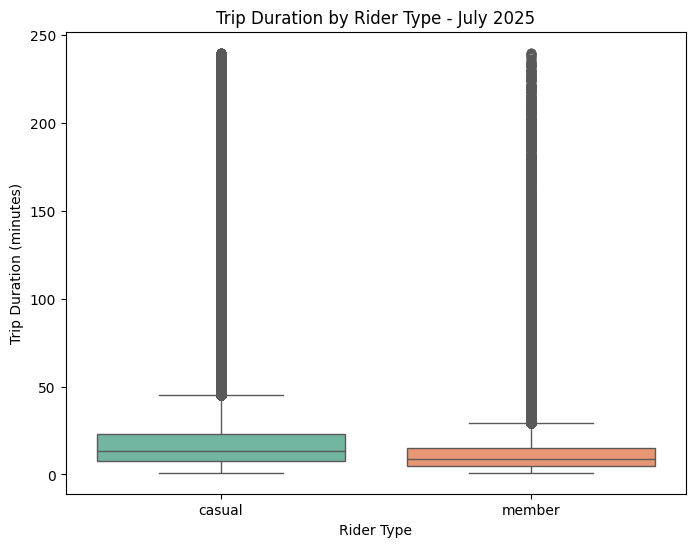

In [21]:
# Graph 2: Trip duration comparison
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='member_casual', y='trip_duration_min', palette='Set2')
plt.title('Trip Duration by Rider Type - July 2025')
plt.xlabel('Rider Type')
plt.ylabel('Trip Duration (minutes)')
plt.show()

Explanation:
These graphs help us see patterns clearly. The first graph (hourly usage) is our main graph that supports the conclusions.
Conclusions and Recommendations for the 2026 World Cup
Key Findings:

Casual riders take longer trips than annual members (confirmed by the t-test).
Casual riders ride more in the evenings and on weekends — typical tourist behavior in summer.
Electric bikes are popular, especially with casual riders.

Recommendations (Marketing & Operations):

Offer special evening or 24-hour day passes for tourists during summer and World Cup time.
Put more electric bikes near tourist spots, Penn Station, ferry terminals, and routes to MetLife Stadium.
Use July 2025 as a baseline to plan for much higher demand in July 2026 around the World Cup Final.

Final Insight:
Focusing marketing on casual (tourist) riders in the evening during summer will help Citi Bike grow ridership and prepare well for the 2026 FIFA World Cup crowds.
References

Citi Bike System Data: https://s3.amazonaws.com/tripdata/index.html
2026 FIFA World Cup information (NY/NJ host venues)